# GEA significance summary — peaks, % of blocks, % of genome

Raw per-record **LFMM** (K=16, no GIF applied), gen 9, MAF>0.05, on the clq0.9
**tiling** partition. 4 variant classes × 22 climate axes (bio1–19 + pc1–3).
A block counts as a **peak** when ≥1 of its records of that class clears
**Bonferroni 0.05/n** within that (class, axis) scan.

Source: `results/multiaxis/raw_block_significance_lfmm{,_union}.csv`
(built by `multiaxis/raw_block_significance.py`). Full method:
`r2_gea_nonsnp/METHODS_lfmm.md`.

### Read this first — three things the numbers do not say on their own

1. **Raw p is uncalibrated.** Genomic inflation λ runs 0.74–3.21 across axes
   (median ≈1.72; 19 of the original 20 axes exceed 1). Every count below is an
   upper bound, and λ is plotted beside it for exactly that reason.
2. **"% of genome" is size-driven.** Tiling block sizes are severely right-skewed
   (median 756 bp, mean 2.04 kb, p99 18.1 kb, max 1.22 Mb) and Bonferroni-hit blocks
   run 10–100× the median. Lead with the **block count**; treat % genome as a ceiling.
3. **Per-axis rows cannot be summed.** The bioclim axes are strongly correlated and
   recur on the same blocks — use the union table at the end.

`nonsnp` is exactly `sv + smallindel` (27,586 + 676,203 = 703,789 records), i.e. a
pooled re-test of the same variants, **not** an independent class. It is reported in
the tables and omitted from the figures so the same records are not drawn twice.

In [1]:
import os, sys
# `__file__` is not defined in a Jupyter kernel, so walk up from cwd to the tree root.
def _tree_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    while d != os.path.dirname(d):
        if os.path.basename(d) == "grenenet_selection" and os.path.exists(os.path.join(d, "lib.py")):
            return d
        d = os.path.dirname(d)
    raise RuntimeError("could not locate the grenenet_selection tree root from " + os.getcwd())
ROOT = _tree_root(); sys.path.insert(0, ROOT)
import numpy as np, pandas as pd, matplotlib.pyplot as plt

MA   = f"{ROOT}/r2_gea_nonsnp/phase1_replication/results/multiaxis"
PLOTS = f"{MA}/plots"; os.makedirs(PLOTS, exist_ok=True)
R = pd.read_csv(f"{MA}/raw_block_significance_lfmm.csv")
U = pd.read_csv(f"{MA}/raw_block_significance_lfmm_union.csv")

CLASSES  = ["snp", "sv", "smallindel", "nonsnp"]     # tables
SERIES   = ["snp", "sv", "smallindel"]               # figures (nonsnp = sv+smallindel)
# categorical palette slots 1-3, light mode; fixed order, never cycled
COL      = {"snp": "#2a78d6", "sv": "#eb6834", "smallindel": "#1baf7a"}
SURFACE  = "#fcfcfb"; INK = "#0b0b0b"; INK2 = "#52514e"; MUTED = "#8a8a85"
plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "axes.edgecolor": MUTED, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "font.size": 9,
})
# axes ordered by lambda (snp) descending -- the ordering IS the argument
LAM = R[R.cls == "snp"].set_index("axis")["lam"]
AXORD = list(LAM.sort_values(ascending=False).index)
print(f"{len(R)} rows = {R.cls.nunique()} classes x {R.axis.nunique()} axes | "
      f"lambda range {R.lam.min():.2f}-{R.lam.max():.2f}")

88 rows = 4 classes x 22 axes | lambda range 0.74-3.21


## 1. Per axis × class — the three measures

Rows are the 22 climate axes **ordered by genomic inflation λ** (most inflated at
top), not alphabetically. Read the panels against that ordering: the hit count falls
away roughly as λ does, which is what inflation alone would produce.

Dot colour = variant class. `nonsnp` omitted (it is `sv`+`smallindel`; see the tables).

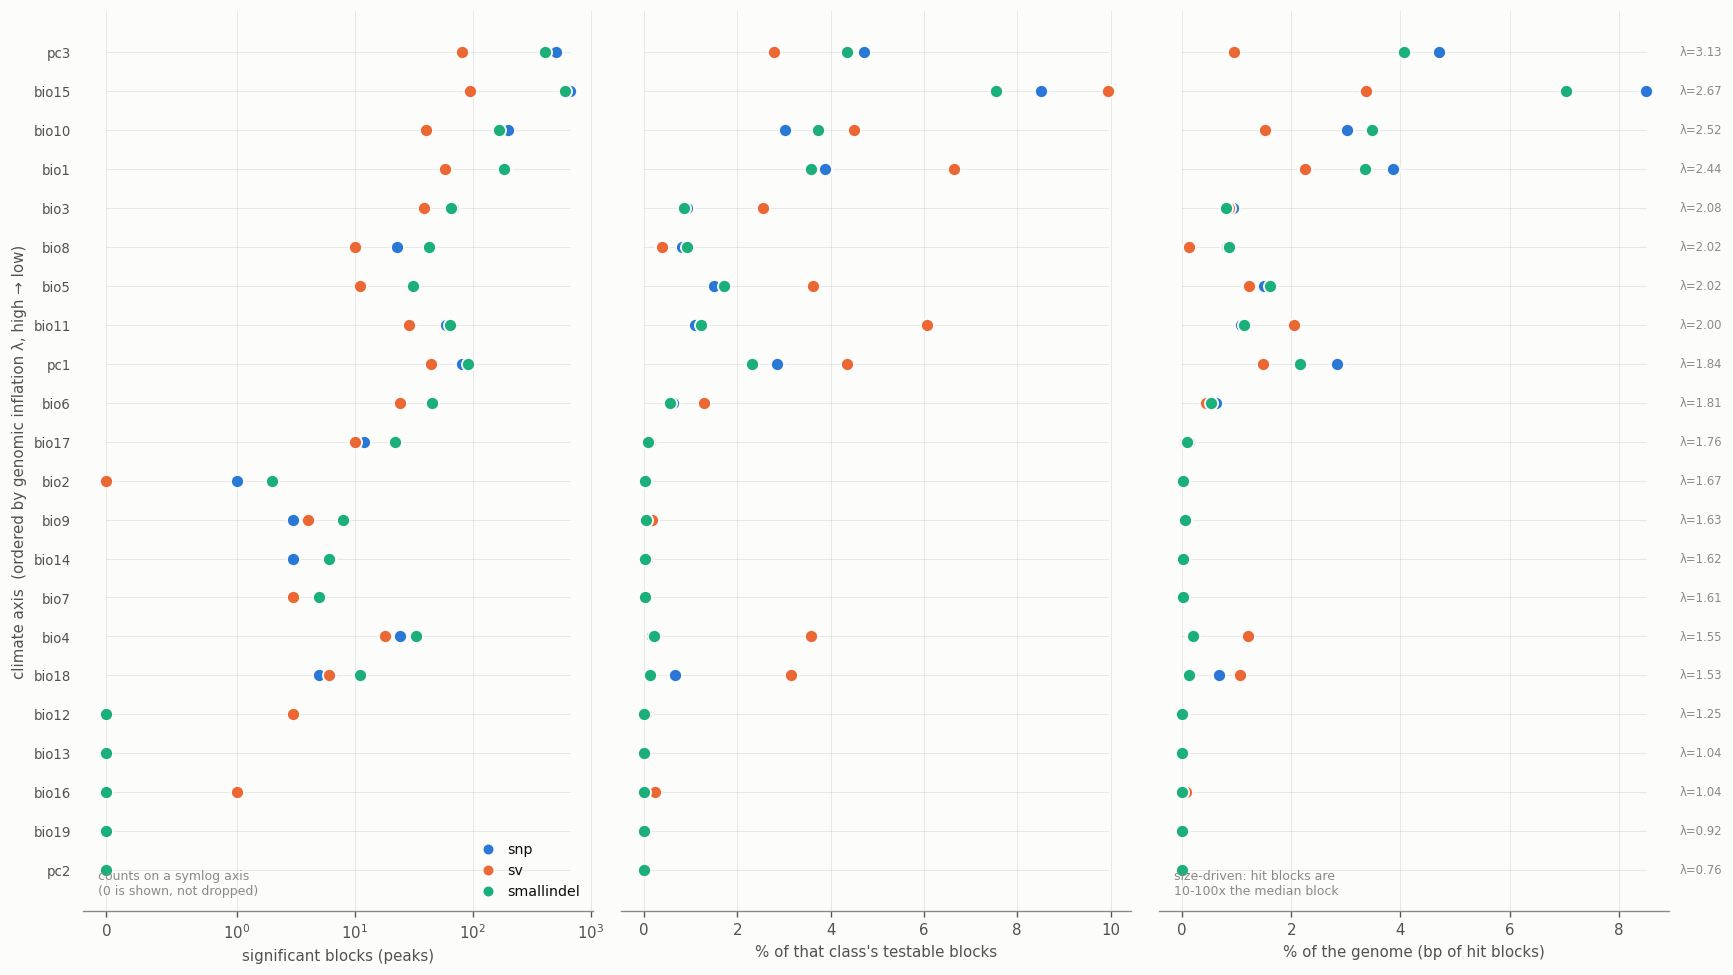

In [2]:
fig, axs = plt.subplots(1, 3, figsize=(14.5, 8.2), sharey=True)
MEAS = [("raw_bonf_blk",     "significant blocks (peaks)",            "count"),
        ("raw_bonf_pcttest", "% of that class's testable blocks",     "percent"),
        ("raw_bonf_pctgen",  "% of the genome (bp of hit blocks)",    "percent")]
ypos = np.arange(len(AXORD))[::-1]

for ax, (col, lab, kind) in zip(axs, MEAS):
    for y, axis in zip(ypos, AXORD):
        ax.plot([0, max(R[col].max(), 1e-9)], [y, y], color=MUTED, lw=.4, alpha=.25, zorder=0)
    for cls in SERIES:
        d = R[R.cls == cls].set_index("axis").reindex(AXORD)
        ax.scatter(d[col].to_numpy(), ypos, s=62, color=COL[cls], edgecolors=SURFACE,
                   linewidths=1.1, zorder=3, label=cls)
    ax.set_xlabel(lab, fontsize=9)
    ax.grid(axis="x", color=MUTED, lw=.4, alpha=.25); ax.set_axisbelow(True)
    ax.tick_params(left=False)          # shared y: no tick marks on any panel
    for sp in ("top", "right", "left"): ax.spines[sp].set_visible(False)
    if kind == "count": ax.set_xscale("symlog", linthresh=1)

axs[0].set_yticks(ypos); axs[0].set_yticklabels(AXORD, fontsize=8)
axs[0].set_ylabel("climate axis  (ordered by genomic inflation \u03bb, high \u2192 low)", fontsize=9, color=INK2)
axs[0].legend(loc="lower right", frameon=False, fontsize=8.5, markerscale=.9,
              handletextpad=.35, labelcolor=INK)
# lambda printed alongside, so the ordering is not just asserted
for y, axis in zip(ypos, AXORD):
    axs[2].annotate(f"\u03bb={LAM[axis]:.2f}", xy=(1.02, y), xycoords=("axes fraction", "data"),
                    va="center", fontsize=7, color=MUTED)
axs[0].annotate("counts on a symlog axis\n(0 is shown, not dropped)", xy=(.03, .015),
                xycoords="axes fraction", fontsize=7.5, color=MUTED, va="bottom")
axs[2].annotate("size-driven: hit blocks are\n10-100x the median block", xy=(.03, .015),
                xycoords="axes fraction", fontsize=7.5, color=MUTED, va="bottom")
fig.tight_layout()
fig.savefig(f"{PLOTS}/significance_by_axis.png", dpi=150, bbox_inches="tight")
plt.show()

### The same numbers as a table

The table view is the accessible companion to the figure above (and carries `nonsnp`,
which the figure omits). `kb_per_blk` is the mean size of a hit block — the
size-confound diagnostic; compare it to the genome-wide mean block of **2.04 kb**.

In [3]:
T = (R[["axis", "cls", "lam", "raw_bonf_rec", "raw_bonf_blk", "n_blocks_tested",
        "raw_bonf_pcttest", "raw_bonf_mb", "raw_bonf_pctgen", "raw_bonf_kb_per_blk"]]
     .rename(columns={"raw_bonf_rec": "sig_records", "raw_bonf_blk": "peaks",
                      "n_blocks_tested": "blocks_tested", "raw_bonf_pcttest": "pct_of_tested",
                      "raw_bonf_mb": "Mb", "raw_bonf_pctgen": "pct_genome",
                      "raw_bonf_kb_per_blk": "kb_per_peak"}))
T["axis"] = pd.Categorical(T["axis"], categories=AXORD, ordered=True)
T["cls"]  = pd.Categorical(T["cls"], categories=CLASSES, ordered=True)
T = T.sort_values(["axis", "cls"]).reset_index(drop=True)
T.to_csv(f"{MA}/significance_summary_by_axis.csv", index=False)
print(f"wrote {MA}/significance_summary_by_axis.csv")
display(T)

wrote /global/scratch/projects/fc_moilab/tbellg/kmate/analysis/grenenet_selection/r2_gea_nonsnp/phase1_replication/results/multiaxis/significance_summary_by_axis.csv


,axis,cls,lam,sig_records,peaks,blocks_tested,pct_of_tested,Mb,pct_genome,kb_per_peak
0,pc3,snp,3.134,1690,506,56846,4.717,5.61,4.707,11.08
1,pc3,sv,3.207,95,81,4520,2.792,1.12,0.944,13.89
2,pc3,smallindel,3.158,798,411,41731,4.353,4.84,4.061,11.77
3,pc3,nonsnp,3.163,808,413,41908,4.099,4.56,3.828,11.04
4,bio15,snp,2.672,2032,665,56846,8.519,10.13,8.499,15.23
...,...,...,...,...,...,...,...,...,...,...
83,bio19,nonsnp,0.966,0,0,41908,0.000,0.00,0.000,0.00
84,pc2,snp,0.761,0,0,56846,0.000,0.00,0.000,0.00
85,pc2,sv,0.757,0,0,4520,0.000,0.00,0.000,0.00
86,pc2,smallindel,0.739,0,0,41731,0.000,0.00,0.000,0.00


## 2. Does λ explain the hit count?

Each dot is one (class, axis). If climate association drove these counts, there would
be no particular relationship with λ. If residual population structure drove them, the
count would rise steeply with λ — which is what the panel shows.

Labelled points are the extremes: **pc2** (the one deflated axis, λ<1, zero hits in
every class) and **pc3 / bio15** (the two most inflated axes, the two largest counts).

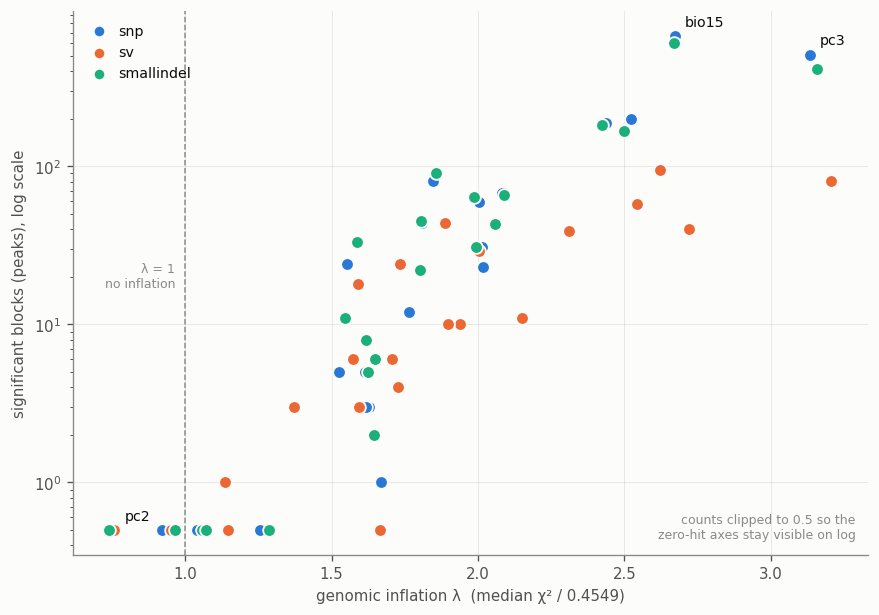

snp: Spearman rho(lambda, peaks) = 0.916 over 22 axes


In [4]:
fig, ax = plt.subplots(figsize=(7.4, 5.2))
for cls in SERIES:
    d = R[R.cls == cls]
    ax.scatter(d["lam"], d["raw_bonf_blk"].clip(lower=0.5), s=58, color=COL[cls],
               edgecolors=SURFACE, linewidths=1.1, zorder=3, label=cls)
ax.axvline(1.0, color=MUTED, lw=.9, ls="--", zorder=1)
ax.set_yscale("log")
# park the caption in the empty band left of the line: the legend occupies the top
# corner and the clipped zero-hit dots occupy the baseline.
ax.annotate("\u03bb = 1\nno inflation", xy=(1.0, 20), xytext=(-6, 0),
            textcoords="offset points", ha="right", va="center", fontsize=7.5, color=MUTED)
ax.set_xlabel("genomic inflation \u03bb  (median \u03c7\u00b2 / 0.4549)", fontsize=9)
ax.set_ylabel("significant blocks (peaks), log scale", fontsize=9)
ax.grid(color=MUTED, lw=.4, alpha=.25); ax.set_axisbelow(True)
for sp in ("top", "right"): ax.spines[sp].set_visible(False)
ax.legend(loc="upper left", frameon=False, fontsize=8.5, markerscale=.9,
          handletextpad=.35, labelcolor=INK)
for axis_lab in ["pc2", "pc3", "bio15"]:
    d = R[(R.cls == "snp") & (R.axis == axis_lab)].iloc[0]
    ax.annotate(axis_lab, xy=(d["lam"], max(d["raw_bonf_blk"], 0.5)), xytext=(6, 6),
                textcoords="offset points", fontsize=8.5, color=INK)
ax.annotate("counts clipped to 0.5 so the\nzero-hit axes stay visible on log",
            xy=(.985, .03), xycoords="axes fraction", ha="right", fontsize=7.5, color=MUTED)
fig.tight_layout()
fig.savefig(f"{PLOTS}/hits_vs_lambda.png", dpi=150, bbox_inches="tight")
plt.show()

r = R[R.cls == "snp"][["lam", "raw_bonf_blk"]]
rho = r["lam"].corr(r["raw_bonf_blk"], method="spearman")
print(f"snp: Spearman rho(lambda, peaks) = {rho:.3f} over {len(r)} axes")

## 3. Union across all 22 axes

**Per-axis rows cannot be summed** — the bioclim axes are correlated and hit the same
blocks repeatedly, so summing double-counts. This is the union: a block counts once if
**any** of the 22 axes flags it. These are the numbers to quote.

clq0.9 tiling partition: 58,376 blocks over 119.1 Mb



,cls,blocks_tested,peaks,pct_of_tested,Mb,pct_genome
0,snp,56846,1430,2.52,15.08,12.66
1,sv,4520,273,6.04,6.70,5.62
2,smallindel,41731,1291,3.09,14.21,11.93
3,nonsnp,41908,1312,3.13,14.39,12.08


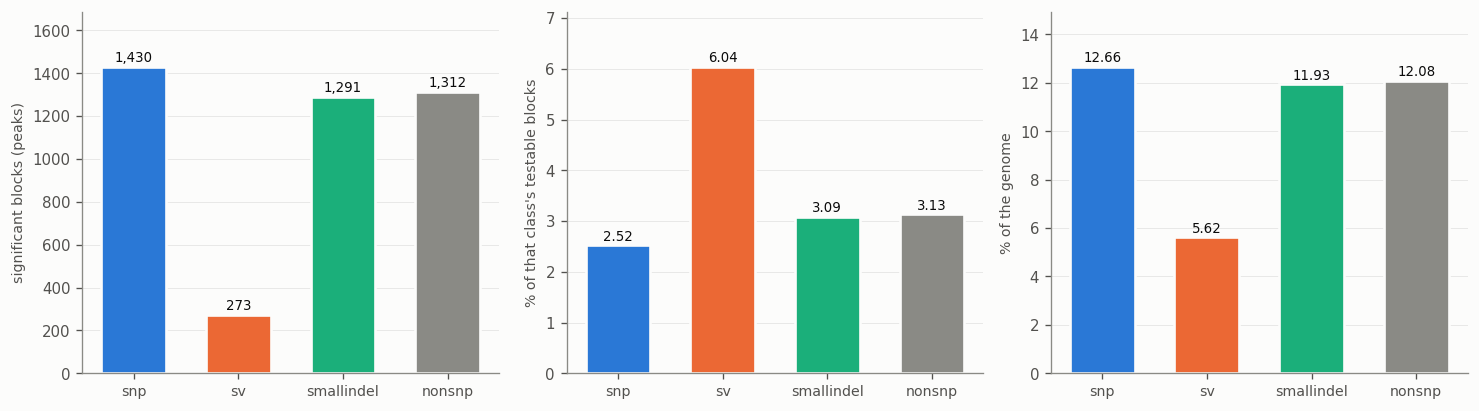

In [5]:
V = U[["cls", "blocks_tested", "raw_bonf_blk", "raw_bonf_pct_of_tested",
       "raw_bonf_mb", "raw_bonf_pctgen"]].rename(columns={
       "raw_bonf_blk": "peaks", "raw_bonf_pct_of_tested": "pct_of_tested",
       "raw_bonf_mb": "Mb", "raw_bonf_pctgen": "pct_genome"})
V["cls"] = pd.Categorical(V["cls"], categories=CLASSES, ordered=True)
V = V.sort_values("cls").reset_index(drop=True)
GENOME_MB = 119.146
print(f"clq0.9 tiling partition: 58,376 blocks over {GENOME_MB:.1f} Mb\n")
display(V)

fig, axs = plt.subplots(1, 3, figsize=(12.4, 3.5))
for ax, (col, lab) in zip(axs, [("peaks", "significant blocks (peaks)"),
                                ("pct_of_tested", "% of that class's testable blocks"),
                                ("pct_genome", "% of the genome")]):
    x = np.arange(len(V))
    ax.bar(x, V[col], width=.62,
           color=[COL.get(c, MUTED) for c in V["cls"]], edgecolor=SURFACE, linewidth=1.6)
    ax.set_xticks(x); ax.set_xticklabels(V["cls"], fontsize=8.5)
    ax.set_ylabel(lab, fontsize=8.5)
    for xi, v in zip(x, V[col]):
        ax.annotate(f"{v:,.0f}" if col == "peaks" else f"{v:.2f}", xy=(xi, v),
                    xytext=(0, 3), textcoords="offset points", ha="center",
                    fontsize=8, color=INK)
    ax.grid(axis="y", color=MUTED, lw=.4, alpha=.25); ax.set_axisbelow(True)
    ax.set_ylim(0, V[col].max() * 1.18)      # headroom so value labels never clip
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
fig.tight_layout()
fig.savefig(f"{PLOTS}/significance_union.png", dpi=150, bbox_inches="tight")
plt.show()

## Takeaway

At raw Bonferroni over 22 climate axes the LFMM scan implicates **1,430 SNP /
1,312 non-SNP / 1,291 smallindel / 273 SV** blocks of 58,376 — **1.8–6.0%** of each
class's testable blocks, and **5.6–12.7%** of the genome by base pairs.

Two qualifications belong with any use of these numbers:

* **The genome fraction is a ceiling.** 1,430 SNP blocks at the *typical* block size
  would cover 2.06 Mb ≈ 1.7% of the genome; they actually cover 12.95 Mb ≈ 10.9%,
  because significant blocks are ~6× larger than average. The block count is the
  honest headline.
* **Counts track λ, not obviously climate.** Axis rank by hit count is close to axis
  rank by inflation. The single most inflated axis (pc3, λ=3.13) yields the
  second-largest count, and the one deflated axis (pc2, λ=0.76) yields zero in every
  class. This does not mean nothing here is real — it means axis-level counts are the
  wrong evidence for realness, and a candidate should be judged on **recurrence across
  axes of differing λ**, not on the size of any one axis's peak list.